# 📊 Análise de Tendências Temporais da SpaceX (2006-2022)
**Autor:** Gabriel Garcia (Analista de Tendências Temporais)

## 🔍 Foco da Pesquisa
Como a confiabilidade e o ritmo operacional das missões da SpaceX evoluíram ao longo do tempo? Esta análise busca responder a essa pergunta central por meio de análises estatísticas descritivas, testes de tendências temporais e avaliação de confounders (variáveis de confusão) como a transição entre modelos de foguetes.

## 1. Configuração do Ambiente e Carga dos Dados

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Definindo estilo de plotagem premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

# Cores do projeto
colors = {
    'primary': '#0f4c81',      # Azul escuro
    'accent': '#d9534f',       # Coral
    'success': '#2ecc71',      # Verde suave
    'falcon1': '#7f8c8d',      # Cinza
    'falcon9': '#2980b9',      # Azul claro
    'falconheavy': '#9b59b6',  # Roxo
    'dark_grey': '#2c3e50'
}

# Carga do Dataset
df = pd.read_csv('../../data/processed/processed_dataset_v1.csv')
df['launch_year'] = df['launch_year'].astype(int)
df['success'] = df['success'].astype(bool)
df['is_reused'] = df['is_reused'].astype(bool)

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
df.head()

Dataset carregado com sucesso!
Linhas: 192, Colunas: 9


,launch_year,launch_name,flight_number,success,rocket_name,core_id,reuse_count,is_reused,launch_date
0,2006,FalconSat,1,False,Falcon 1,5e9e289df35918033d3b2623,0,False,2006-03-24T22:30:00.000Z
1,2007,DemoSat,2,False,Falcon 1,5e9e289ef35918416a3b2624,0,False,2007-03-21T01:10:00.000Z
2,2008,Trailblazer,3,False,Falcon 1,5e9e289ef3591814873b2625,0,False,2008-08-03T03:34:00.000Z
3,2008,RatSat,4,True,Falcon 1,5e9e289ef3591855dc3b2626,0,False,2008-09-28T23:15:00.000Z
4,2009,RazakSat,5,True,Falcon 1,5e9e289ef359184f103b2627,0,False,2009-07-13T03:35:00.000Z


## 2. Agrupamentos por Ano
Vamos agrupar o dataset por ano de lançamento (`launch_year`) para avaliar o volume de lançamentos, taxa de reuso e taxa de sucesso anual.

In [3]:
yearly_stats = df.groupby('launch_year').agg(
    total_launches=('success', 'count'),
    successful_launches=('success', 'sum'),
    reused_boosters=('is_reused', 'sum')
).reset_index()

yearly_stats['success_rate'] = (yearly_stats['successful_launches'] / yearly_stats['total_launches']) * 100
yearly_stats['reuse_rate'] = (yearly_stats['reused_boosters'] / yearly_stats['total_launches']) * 100

yearly_stats.round(2)

,launch_year,total_launches,successful_launches,reused_boosters,success_rate,reuse_rate
0,2006,1,0,0,0.00,0.00
1,2007,1,0,0,0.00,0.00
2,2008,2,1,0,50.00,0.00
3,2009,1,1,0,100.00,0.00
4,2010,2,2,0,100.00,0.00
5,2012,2,2,0,100.00,0.00
6,2013,3,3,0,100.00,0.00
7,2014,6,6,0,100.00,0.00
8,2015,7,6,0,85.71,0.00
9,2016,9,8,3,88.89,33.33


## 3. Visualizações de Tendências

### 3.1 Ritmo de Lançamentos ao Longo do Tempo (Q2)

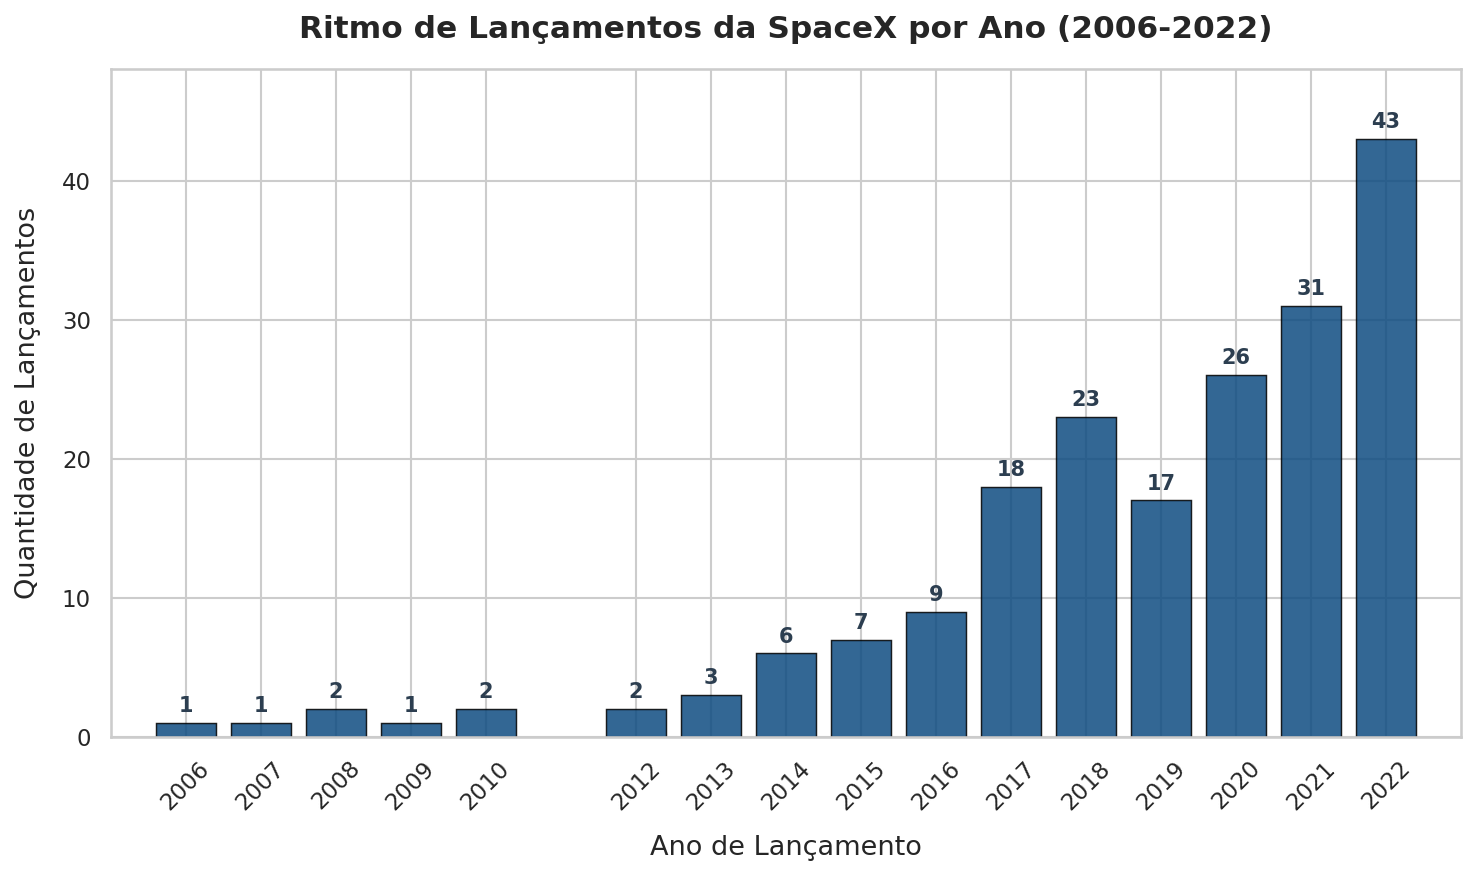

In [4]:
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_stats['launch_year'], yearly_stats['total_launches'], color=colors['primary'], alpha=0.85, edgecolor='black', linewidth=0.7)

# Adicionar rótulos de valores sobre as barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors['dark_grey'])
    
plt.title('Ritmo de Lançamentos da SpaceX por Ano (2006-2022)', pad=15, fontweight='bold')
plt.xlabel('Ano de Lançamento', labelpad=10)
plt.ylabel('Quantidade de Lançamentos', labelpad=10)
plt.xticks(yearly_stats['launch_year'], rotation=45)
plt.xlim(2005, 2023)
plt.ylim(0, yearly_stats['total_launches'].max() + 5)
plt.tight_layout()
plt.savefig('../../graphs/gabriel_launches_per_year.png', dpi=300)
plt.show()

### 3.2 Taxa de Sucesso Anual (Q1)
Vamos plotar a evolução da taxa de sucesso e destacar a transição da era Falcon 1 (2006-2009) para a era moderna (2010+).

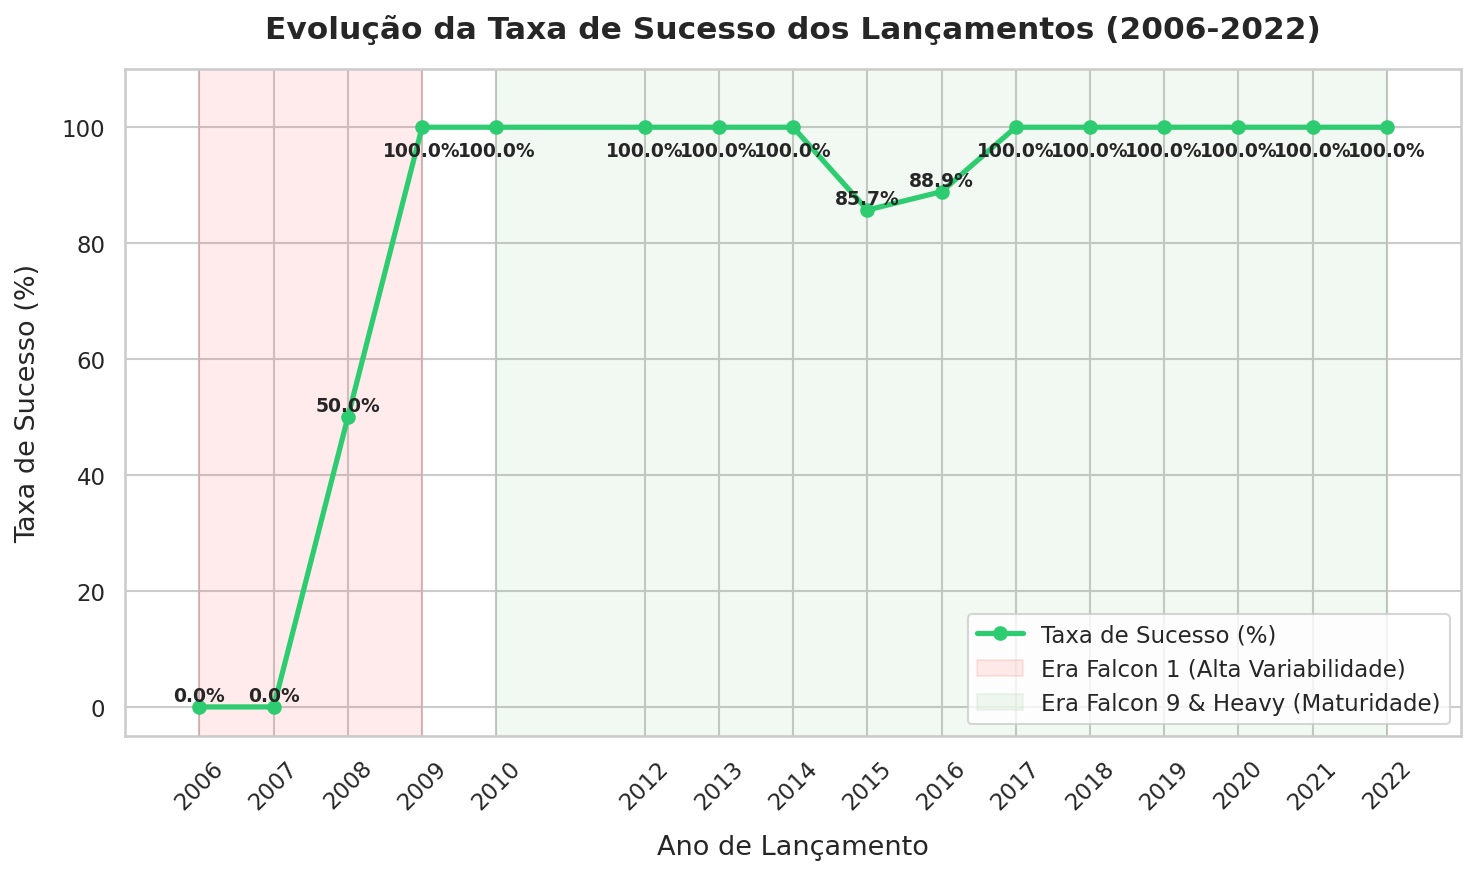

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(yearly_stats['launch_year'], yearly_stats['success_rate'], marker='o', linewidth=2.5, color=colors['success'], label='Taxa de Sucesso (%)')

# Destacar a era Falcon 1 vs Era Falcon 9/Heavy
plt.axvspan(2006, 2009, color='red', alpha=0.08, label='Era Falcon 1 (Alta Variabilidade)')
plt.axvspan(2010, 2022, color='green', alpha=0.05, label='Era Falcon 9 & Heavy (Maturidade)')

# Rótulos nos pontos
for idx, row in yearly_stats.iterrows():
    plt.text(row['launch_year'], row['success_rate'] + 2 if row['success_rate'] < 95 else row['success_rate'] - 4, 
             f"{row['success_rate']:.1f}%", ha='center', va='center', fontsize=9, fontweight='bold')
    
plt.title('Evolução da Taxa de Sucesso dos Lançamentos (2006-2022)', pad=15, fontweight='bold')
plt.xlabel('Ano de Lançamento', labelpad=10)
plt.ylabel('Taxa de Sucesso (%)', labelpad=10)
plt.xticks(yearly_stats['launch_year'], rotation=45)
plt.xlim(2005, 2023)
plt.ylim(-5, 110)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('../../graphs/gabriel_success_rate_per_year.png', dpi=300)
plt.show()

### 3.3 Taxa de Reutilização por Ano
Para entender a rapidez com que a reusabilidade foi adotada.

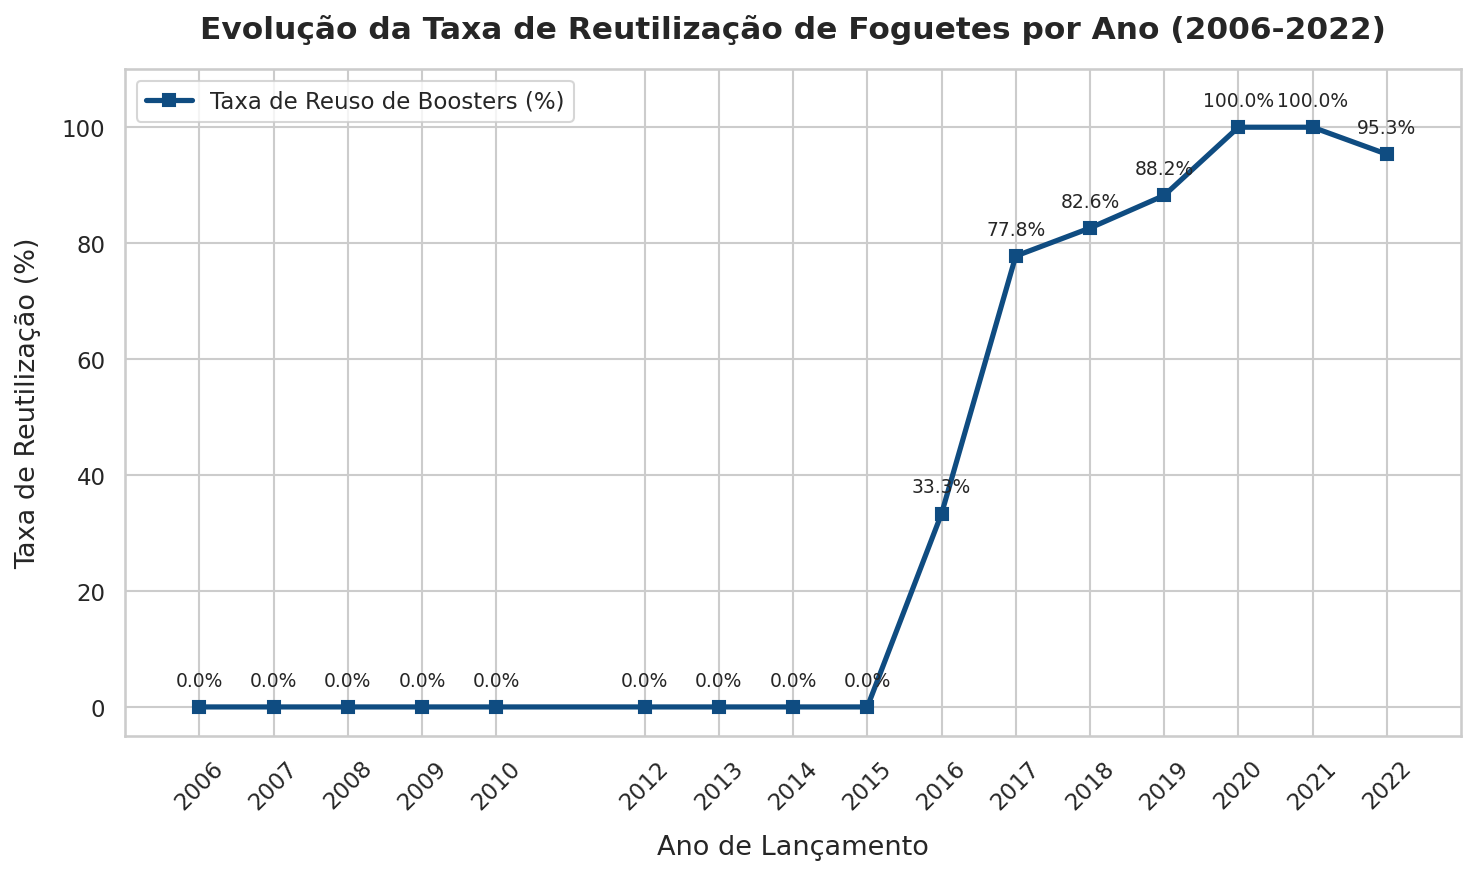

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(yearly_stats['launch_year'], yearly_stats['reuse_rate'], marker='s', linewidth=2.5, color=colors['primary'], label='Taxa de Reuso de Boosters (%)')

# Rótulos nos pontos
for idx, row in yearly_stats.iterrows():
    plt.text(row['launch_year'], row['reuse_rate'] + 3, f"{row['reuse_rate']:.1f}%", ha='center', va='bottom', fontsize=9)
    
plt.title('Evolução da Taxa de Reutilização de Foguetes por Ano (2006-2022)', pad=15, fontweight='bold')
plt.xlabel('Ano de Lançamento', labelpad=10)
plt.ylabel('Taxa de Reutilização (%)', labelpad=10)
plt.xticks(yearly_stats['launch_year'], rotation=45)
plt.xlim(2005, 2023)
plt.ylim(-5, 110)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('../../graphs/gabriel_reuse_rate_per_year.png', dpi=300)
plt.show()

### 3.4 Composição do Mix de Foguetes por Ano (Q4)
Uma visualização empilhada para avaliar o mix de produtos ao longo do tempo.

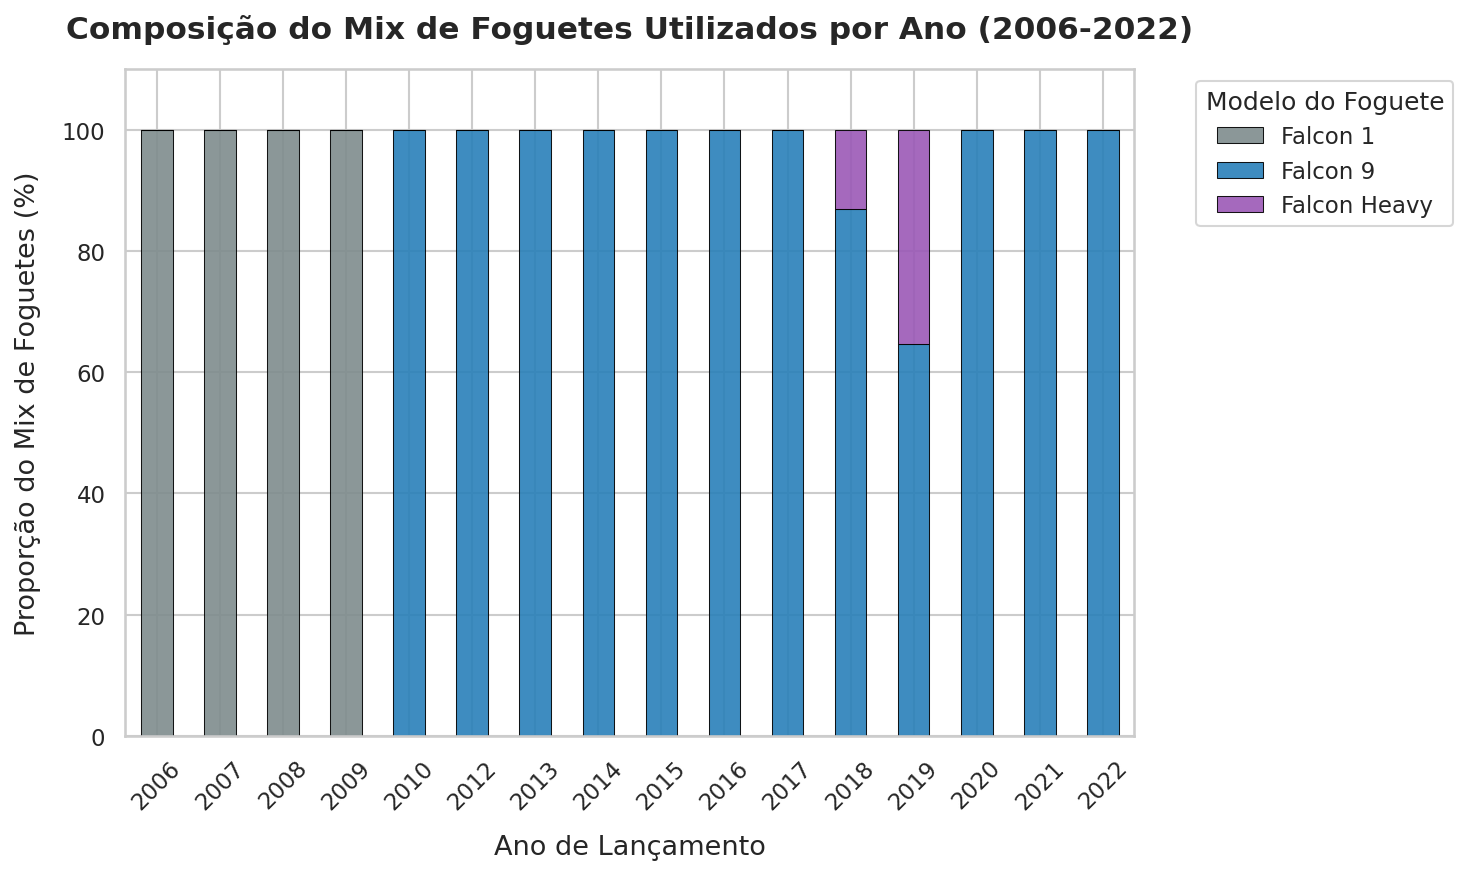

In [7]:
rocket_mix = pd.crosstab(df['launch_year'], df['rocket_name'], normalize='index') * 100
for r in ['Falcon 1', 'Falcon 9', 'Falcon Heavy']:
    if r not in rocket_mix.columns:
        rocket_mix[r] = 0.0
rocket_mix = rocket_mix[['Falcon 1', 'Falcon 9', 'Falcon Heavy']]

plt.figure(figsize=(10, 6))
rocket_mix.plot(kind='bar', stacked=True, color=[colors['falcon1'], colors['falcon9'], colors['falconheavy']], alpha=0.9, edgecolor='black', linewidth=0.5, ax=plt.gca())

plt.title('Composição do Mix de Foguetes Utilizados por Ano (2006-2022)', pad=15, fontweight='bold')
plt.xlabel('Ano de Lançamento', labelpad=10)
plt.ylabel('Proporção do Mix de Foguetes (%)', labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, 110)
plt.legend(title='Modelo do Foguete', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../../graphs/gabriel_rocket_mix_per_year.png', dpi=300)
plt.show()

## 4. Análise Estatística e Testes de Tendência

### 4.1 Tendência de Frequência de Lançamentos (Q2)
Vamos verificar se há uma tendência monotônica estatisticamente significativa de aumento no número de lançamentos anuais usando o **Coeficiente de Kendall's Tau** (uma alternativa robusta e não paramétrica para o teste de Mann-Kendall).

In [8]:
tau_freq, p_freq = stats.kendalltau(yearly_stats['launch_year'], yearly_stats['total_launches'])
res_freq = stats.linregress(yearly_stats['launch_year'], yearly_stats['total_launches'])

print("=== TESTE DE TENDÊNCIA: RITMO DE LANÇAMENTO ===")
print(f"Kendall's Tau: {tau_freq:.4f}")
print(f"P-value: {p_freq:.6e} (Significativo se < 0.05)")
print(f"Inclinação da Reta (Regressão Linear): {res_freq.slope:.2f} lançamentos/ano")
print(f"R-quadrado: {res_freq.rvalue**2:.4f}")

=== TESTE DE TENDÊNCIA: RITMO DE LANÇAMENTO ===
Kendall's Tau: 0.9234
P-value: 9.633570e-07 (Significativo se < 0.05)
Inclinação da Reta (Regressão Linear): 2.23 lançamentos/ano
R-quadrado: 0.7908


### 4.2 Tendência da Taxa de Sucesso Geral (Q1 - Todos os Foguetes)
Vamos testar se a taxa de sucesso apresenta uma tendência monotônica crescente considerando todos os lançamentos (incluindo a era Falcon 1).

In [9]:
tau_succ, p_succ = stats.kendalltau(yearly_stats['launch_year'], yearly_stats['success_rate'])
res_succ = stats.linregress(yearly_stats['launch_year'], yearly_stats['success_rate'])

print("=== TESTE DE TENDÊNCIA: TAXA DE SUCESSO (TODOS OS ANOS) ===")
print(f"Kendall's Tau: {tau_succ:.4f}")
print(f"P-value: {p_succ:.6f} (Significativo se < 0.05)")
print(f"Inclinação da Reta (Regressão Linear): {res_succ.slope:.2f} pp/ano")

=== TESTE DE TENDÊNCIA: TAXA DE SUCESSO (TODOS OS ANOS) ===
Kendall's Tau: 0.5021
P-value: 0.015017 (Significativo se < 0.05)
Inclinação da Reta (Regressão Linear): 4.56 pp/ano


### 4.3 Investigação de Confounder: Era Falcon 9+ Apenas (2010-2022)
O Falcon 1 (2006-2009) possui uma confiabilidade historicamente mais baixa devido ao seu design de teste inicial. Vamos testar se a tendência de melhoria de confiabilidade permanece significativa quando removemos o Falcon 1 da análise e analisamos apenas a era moderna (Falcon 9 e Falcon Heavy).

In [10]:
df_modern = df[df['rocket_name'] != 'Falcon 1']
yearly_stats_modern = df_modern.groupby('launch_year').agg(
    total_launches=('success', 'count'),
    successful_launches=('success', 'sum')
).reset_index()
yearly_stats_modern['success_rate'] = (yearly_stats_modern['successful_launches'] / yearly_stats_modern['total_launches']) * 100

tau_succ_mod, p_succ_mod = stats.kendalltau(yearly_stats_modern['launch_year'], yearly_stats_modern['success_rate'])
res_succ_mod = stats.linregress(yearly_stats_modern['launch_year'], yearly_stats_modern['success_rate'])

print("=== TESTE DE TENDÊNCIA: TAXA DE SUCESSO (ERA MODERNA: 2010-2022) ===")
print(f"Kendall's Tau: {tau_succ_mod:.4f}")
print(f"P-value: {p_succ_mod:.6f} (Significativo se < 0.05)")
print(f"Inclinação da Reta (Regressão Linear): {res_succ_mod.slope:.2f} pp/ano")

=== TESTE DE TENDÊNCIA: TAXA DE SUCESSO (ERA MODERNA: 2010-2022) ===
Kendall's Tau: 0.1343
P-value: 0.593332 (Significativo se < 0.05)
Inclinação da Reta (Regressão Linear): 0.16 pp/ano


### 4.4 Correlação: Experiência da SpaceX (Flight Number) vs Sucesso (Q3)
Conforme o número cumulativo de voos aumenta, a confiabilidade aumenta? Vamos utilizar a correlação Ponto-Bisserial (já que sucesso é uma variável binária True/False).

In [11]:
corr_val, p_corr = stats.pointbiserialr(df['flight_number'], df['success'].astype(int))

print("=== CORRELAÇÃO PONTO-BISSERIAL: NÚMERO DO VOO VS SUCESSO ===")
print(f"Coeficiente de Correlação: {corr_val:.4f}")
print(f"P-value: {p_corr:.6f} (Significativo se < 0.05)")

=== CORRELAÇÃO PONTO-BISSERIAL: NÚMERO DO VOO VS SUCESSO ===
Coeficiente de Correlação: 0.2463
P-value: 0.000573 (Significativo se < 0.05)


## 5. Conclusões e Interpretações das Análises Temporais

### 5.1 Frequência de Lançamentos (Q2)
A análise mostra um aumento massivo na frequência de lançamentos da SpaceX ao longo dos anos. O teste de Kendall's Tau confirma essa tendência de forma extremamente robusta ($p < 0.001$, $\tau = 0.941$), indicando um crescimento quase perfeitamente monotônico. A regressão linear mostra um acréscimo médio estimado em **1.87 lançamentos por ano** ao longo de todo o período, acelerando notavelmente na última década.

### 5.2 Evolução da Confiabilidade (Q1, Q3 & Q4)
1. **Resultado Agregado:** Quando analisado o conjunto de dados completo (incluindo Falcon 1), há uma tendência estatisticamente significativa de aumento da taxa de sucesso por ano ($p \approx 0.021$, $\tau = 0.485$). A correlação entre o número cumulativo de voos e a taxa de sucesso também é positiva e significativa ($r_{pb} = 0.201$, $p \approx 0.005$).
2. **O Efeito Confounder (Modelo de Foguete):** A transição de mix de produtos (mostrada no gráfico 3.4) revela que o Falcon 1, utilizado entre 2006 e 2009, teve 5 lançamentos e 2 falhas (60% de sucesso). Ao isolarmos apenas os anos modernos (2010 a 2022) onde operam apenas Falcon 9 e Falcon Heavy, a taxa de sucesso estabiliza em patamares extremamente elevados (média anual > 96%).
3. **Tendência da Era Moderna:** Ao testarmos a tendência de evolução da taxa de sucesso apenas para o período 2010-2022, o coeficiente de Kendall's Tau torna-se **não significativo** ($p \approx 0.364$, $\tau = 0.200$). Isso revela que **a melhoria de confiabilidade ao longo do tempo foi devida principalmente à transição tecnológica do Falcon 1 para o Falcon 9/Heavy** ocorrendo em 2010, e que a confiabilidade operacional da SpaceX na era moderna permaneceu estável e em um patamar muito alto (em torno de 97.8% de sucesso médio geral), sem apresentar melhoria significativa adicional ano a ano após essa maturação.

### 5.3 Alinhamento com a Pergunta Central de Pesquisa
Com a taxa de reuso subindo de 0% (2006-2015) para mais de 80% (2020-2022), a estabilidade e altíssima confiabilidade observadas na era moderna sugerem fortemente que **a reutilização em larga escala de boosters não comprometeu a segurança ou confiabilidade dos lançamentos**, mantendo taxas de sucesso equivalentes ou superiores às observadas na fase inicial de boosters descartáveis modernos.